# Baseline: Active Lesion Localization

Name 1: Muhammad Hamdan Sikandar

Rollnumber 1: 27100326

Name 2: Hadi Shazad Khan

Rollnumber 2: 27100475

Reference active-localization model evaluated with the standardized report metrics.


## Imports and Configuration

Loads dependencies, constants, output paths, and report metadata.


In [1]:
import os
import json
import math
import csv
import random
import time
from collections import deque, namedtuple
from pathlib import Path
import builtins

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import nibabel as nib
from scipy.ndimage import label, find_objects

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from IPython.display import display

RUN_VERBOSE = False

def log_line(*args, **kwargs):
    if RUN_VERBOSE:
        builtins.print(*args, **kwargs)

try:
    import torchvision
    from torchvision import models
    from torchvision.transforms import functional as TF
except Exception as e:
    torchvision = None
    models = None
    log_line(f'WARNING: torchvision import failed: {e}')


RAW_DIR = '/kaggle/input/datasets/javariatahir123/lits17-liver-tumor-segmentation'
VOL_DIR = os.path.join(RAW_DIR, 'CT_Vol', 'CT_Vol')
SEG_DIR = os.path.join(RAW_DIR, 'CT_Mask', 'CT_Mask')
OUT_DIR = '/kaggle/working/caicedo_baseline_final'
os.makedirs(OUT_DIR, exist_ok=True)


NUM_VOLUMES       = 131
HU_MIN, HU_MAX    = -200, 300
MIN_LESION_VOXELS = 10
MIN_BBOX_DIM      = 4
SEED              = 42

IMG_SIZE          = 224
CONTEXT_PAD_PX    = 16
HISTORY_LEN       = 10
NUM_ACTIONS       = 9
ALPHA             = 0.20
MAX_STEPS         = 40
TRIGGER_IOU       = 0.50
TRIGGER_REWARD    = 3.0
MIN_BOX_SIZE      = 8
REWARD_MODE       = 'any'
LABEL_SOURCE      = 'slice_2d_components'
USE_LARGEST_LESION_PER_VOLUME = False
TRIGGER_DEMO_PROB         = 1.00
TRIGGER_POSITIVE_REPLAY   = 4
TRIGGER_NEGATIVE_REPLAY   = 1
TRIGGER_NEGATIVE_MIN_IOU  = 0.35
STAGNATION_PATIENCE       = 8
STAGNATION_TRIGGER_IOU    = 0.40
SUPPRESS_REVERSALS        = True
MASK_NOOP_ACTIONS         = True
BOX_FEATURE_DIM           = 8


DEVICE            = 'cuda' if torch.cuda.is_available() else 'cpu'
FAST_DEV_RUN      = False
TRAIN_EPOCHS      = 8
MAX_TRAIN_RECORDS = 300
MAX_VAL_RECORDS   = 100
MAX_TEST_RECORDS  = None
BATCH_SIZE        = 32
GAMMA             = 0.95
LR                = 1e-4
REPLAY_SIZE       = 50_000
LEARNING_STARTS   = 200 if FAST_DEV_RUN else 500
TARGET_UPDATE_EVERY = 500
TRAIN_EVERY       = 1
EPS_START         = 1.0
EPS_END           = 0.05
DROPOUT           = 0.5
GUIDED_EXPLORATION = True

EPS_ANNEAL_EPOCHS = 1 if FAST_DEV_RUN else max(1, min(6, TRAIN_EPOCHS - 1))

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

log_line(f'device={DEVICE}')
log_line(f'output dir={OUT_DIR}')
log_line(f'FAST_DEV_RUN={FAST_DEV_RUN}, epochs={TRAIN_EPOCHS}')
log_line(f'train cap: {MAX_TRAIN_RECORDS}, val cap: {MAX_VAL_RECORDS}')

experiment_card_df = pd.DataFrame([
    {"field": "project_title", "value": "Baseline: Active Lesion Localization"},
    {"field": "name_1", "value": ""},
    {"field": "name_2", "value": ""},
    {"field": "roll_1", "value": ""},
    {"field": "roll_2", "value": ""},
    {"field": "experiment_name", "value": "Baseline"},
    {"field": "device", "value": DEVICE},
    {"field": "seed", "value": SEED},
    {"field": "max_steps", "value": MAX_STEPS},
    {"field": "reward_mode", "value": REWARD_MODE},
    {"field": "trigger_iou", "value": TRIGGER_IOU},
])
display(experiment_card_df)


,field,value
0,project_title,Baseline: Active Lesion Localization
1,name_1,
2,name_2,
3,roll_1,
4,roll_2,
5,experiment_name,Baseline
6,device,cuda
7,seed,42
8,max_steps,40
9,reward_mode,any


## Metadata Loader

Builds or loads lesion metadata and split definitions.


In [2]:
def find_nii(data_dir, prefix, idx):
    for ext in ('.nii', '.nii.gz'):
        for name in (f'{prefix}-{idx}{ext}', f'{prefix}_{idx}{ext}', f'{prefix}-{idx:03d}{ext}'):
            p = os.path.join(data_dir, name)
            if os.path.exists(p):
                return p
    return None


def window_norm(vol, lo=HU_MIN, hi=HU_MAX):
    return ((np.clip(vol, lo, hi) - lo) / (hi - lo)).astype(np.float32)


def extract_bboxes_3d(seg, shape):
    tumor = (seg == 2).astype(np.uint8)
    labeled, n = label(tumor)
    if n == 0:
        return []
    lesions = []
    for i, slc in enumerate(find_objects(labeled)):
        if slc is None:
            continue
        voxels = int(np.sum(labeled[slc] == i + 1))
        if voxels < MIN_LESION_VOXELS:
            continue
        bbox = np.array([[s.start, s.stop] for s in slc], dtype=np.int64)
        for ax in range(3):
            d = bbox[ax, 1] - bbox[ax, 0]
            if d < MIN_BBOX_DIM:
                pad = MIN_BBOX_DIM - d
                bbox[ax, 0] = max(0, bbox[ax, 0] - pad // 2)
                bbox[ax, 1] = min(shape[ax], bbox[ax, 0] + MIN_BBOX_DIM)
        lesions.append({'bbox': bbox.tolist(), 'voxels': voxels,
                        'dims_vox': (bbox[:, 1] - bbox[:, 0]).tolist()})
    return lesions


def build_or_load_metadata():
    meta_path  = os.path.join(OUT_DIR, 'metadata.json')
    split_path = os.path.join(OUT_DIR, 'splits.json')
    if os.path.exists(meta_path) and os.path.exists(split_path):
        with open(meta_path) as f:
            metadata = json.load(f)
        with open(split_path) as f:
            splits = json.load(f)
        log_line(f'Loaded metadata: {len(metadata)} volumes')
        return metadata, splits
    metadata = {}
    for vid in range(NUM_VOLUMES):
        vp = find_nii(VOL_DIR, 'volume', vid)
        sp = find_nii(SEG_DIR, 'segmentation', vid)
        if vp is None or sp is None:
            log_line(f'skip vol {vid}: missing')
            continue
        vol_nii = nib.load(vp)
        seg     = nib.load(sp).get_fdata()
        spacing = [float(x) for x in vol_nii.header.get_zooms()[:3]]
        lesions = extract_bboxes_3d(seg, seg.shape)
        for les in lesions:
            les['dims_mm']     = [float(d * s) for d, s in zip(les['dims_vox'], spacing)]
            les['diameter_mm'] = max(les['dims_mm'])
        metadata[str(vid)] = {'shape': list(seg.shape), 'spacing': spacing,
                               'num_lesions': len(lesions), 'lesions': lesions}
        if vid % 10 == 0:
            log_line(f'vol {vid}: shape={seg.shape}, lesions={len(lesions)}')
    vol_ids = sorted(int(k) for k, v in metadata.items() if v['num_lesions'] > 0)
    rng = np.random.RandomState(SEED)
    rng.shuffle(vol_ids)
    n = len(vol_ids)
    n_train = int(0.76 * n); n_val = int(0.12 * n)
    splits  = {'train': sorted(vol_ids[:n_train]),
                'val':   sorted(vol_ids[n_train:n_train + n_val]),
                'test':  sorted(vol_ids[n_train + n_val:])}
    with open(meta_path,  'w') as f: json.dump(metadata, f)
    with open(split_path, 'w') as f: json.dump(splits, f)
    log_line(f'Built metadata: {len(metadata)} volumes')
    return metadata, splits


METADATA, SPLITS = build_or_load_metadata()
for split, ids in SPLITS.items():
    n_les = sum(METADATA[str(v)]['num_lesions'] for v in ids)
    log_line(f'{split:5s}: {len(ids):3d} volumes, {n_les:4d} 3D lesions')

split_summary_df = pd.DataFrame([
    {"split": split, "volumes": len(ids), "lesions_3d": sum(METADATA[str(v)]["num_lesions"] for v in ids)}
    for split, ids in SPLITS.items()
])
display(split_summary_df)


,split,volumes,lesions_3d
0,train,89,624
1,val,14,132
2,test,15,128


## 2D Lesion Records

Converts lesion masks into axial 2D localization records.


In [3]:
def bbox3d_to_axial_box2d(bbox3d):
    b = np.asarray(bbox3d, dtype=np.int64)
    return np.array([int(b[1,0]), int(b[0,0]), int(b[1,1]), int(b[0,1])], dtype=np.int64)


def lesion_center_slice(bbox3d):
    b = np.asarray(bbox3d, dtype=np.int64)
    return int((b[2, 0] + b[2, 1] - 1) // 2)


def box2d_size_mm(box, spacing):
    x1, y1, x2, y2 = map(float, box)
    width_mm  = max(0.0, x2 - x1) * float(spacing[1])
    height_mm = max(0.0, y2 - y1) * float(spacing[0])
    return float(max(width_mm, height_mm)), float(width_mm * height_mm)


def slice_component_boxes(seg, z):
    mask = (seg[:, :, int(z)] == 2).astype(np.uint8)
    labeled, n = label(mask)
    boxes = []
    if n == 0: return boxes
    for i, slc in enumerate(find_objects(labeled)):
        if slc is None: continue
        component = labeled[slc] == (i + 1)
        area_px   = int(component.sum())
        if area_px == 0: continue
        y1, y2 = int(slc[0].start), int(slc[0].stop)
        x1, x2 = int(slc[1].start), int(slc[1].stop)
        if (x2 - x1) >= 2 and (y2 - y1) >= 2:
            boxes.append({'box': [x1, y1, x2, y2], 'area_px': area_px})
    return boxes


def choose_target_slice_box(component_boxes, projected_target_box):
    if not component_boxes: return None
    proj = np.asarray(projected_target_box, dtype=np.float32)
    def overlap_area(box):
        box = np.asarray(box, dtype=np.float32)
        return max(0.0, min(proj[2], box[2]) - max(proj[0], box[0])) * max(0.0, min(proj[3], box[3]) - max(proj[1], box[1]))
    best = max(component_boxes, key=lambda item: (overlap_area(item['box']), item['area_px']))
    return best if overlap_area(best['box']) > 0 else None


def build_2d_records(split):
    records = []
    for vid in SPLITS[split]:
        info = METADATA[str(vid)]
        sp   = find_nii(SEG_DIR, 'segmentation', int(vid))
        if sp is None: raise FileNotFoundError(f'segmentation {vid} not found')
        seg  = nib.load(sp).get_fdata().astype(np.int16)
        for target_idx, target_les in enumerate(info['lesions']):
            z = lesion_center_slice(target_les['bbox'])
            projected_target_box = bbox3d_to_axial_box2d(target_les['bbox']).tolist()
            component_boxes      = slice_component_boxes(seg, z)
            target_component     = choose_target_slice_box(component_boxes, projected_target_box)
            if target_component is None: continue
            boxes = [item['box'] for item in component_boxes]
            target_2d_diameter_mm, _ = box2d_size_mm(target_component['box'], info['spacing'])
            records.append({
                'vid': int(vid), 'slice': int(z), 'target_idx': int(target_idx),
                'target_box': target_component['box'], 'boxes': boxes,
                'projected_3d_target_box': projected_target_box,
                'target_area_px': int(target_component['area_px']),
                'target_2d_diameter_mm': target_2d_diameter_mm,
                'diameter_mm': target_2d_diameter_mm,
                'diameter_3d_mm': float(target_les['diameter_mm']),
                'shape2d': [int(info['shape'][0]), int(info['shape'][1])],
            })
    return records


RECORDS = {split: build_2d_records(split) for split in ['train', 'val', 'test']}
for split, recs in RECORDS.items():
    log_line(f'{split:5s}: {len(recs):4d} 2D records')
assert len(RECORDS['train']) > 0, 'No training records built'

record_summary_df = pd.DataFrame([
    {"split": split, "records_2d": len(recs)}
    for split, recs in RECORDS.items()
])
display(record_summary_df)


,split,records_2d
0,train,623
1,val,132
2,test,128


## Volume Cache and Visual Check

Caches volumes and renders a quick record-level sanity check.


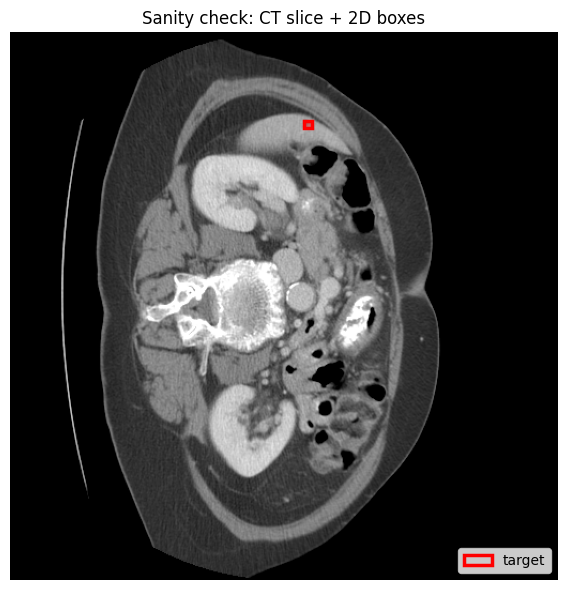

In [4]:
class VolumeCache:
    def __init__(self, max_size=16):
        self.max_size = max_size; self.cache = {}; self.order = []
    def get_volume(self, vid):
        key = ('vol', int(vid))
        if key in self.cache: return self.cache[key]
        p = find_nii(VOL_DIR, 'volume', int(vid))
        vol = window_norm(nib.load(p).get_fdata().astype(np.float32))
        self._put(key, vol); return vol
    def get_seg(self, vid):
        key = ('seg', int(vid))
        if key in self.cache: return self.cache[key]
        p = find_nii(SEG_DIR, 'segmentation', int(vid))
        seg = nib.load(p).get_fdata().astype(np.int16)
        self._put(key, seg); return seg
    def _put(self, key, value):
        if len(self.order) >= self.max_size:
            self.cache.pop(self.order.pop(0), None)
        self.cache[key] = value; self.order.append(key)

CACHE = VolumeCache()

def draw_boxes(ax, boxes, color='red', linewidth=2, label=None, linestyle='-'):
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(float, box)
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
            linewidth=linewidth, edgecolor=color, facecolor='none',
            linestyle=linestyle, label=label if i==0 else None))

def show_record(record, title=None):
    vol = CACHE.get_volume(record['vid']); seg = CACHE.get_seg(record['vid'])
    z = record['slice']; img = vol[:, :, z]; mask = (seg[:, :, z] == 2)
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.imshow(np.ma.masked_where(~mask, mask), cmap='autumn', alpha=0.35)
    other_boxes = [b for b in record['boxes'] if list(b) != list(record['target_box'])]
    draw_boxes(ax, other_boxes, color='orange', linewidth=1.5, label='other lesion')
    draw_boxes(ax, [record['target_box']], color='red', linewidth=2.5, label='target')
    ax.set_title(title or f'vol={record["vid"]} slice={z}')
    ax.axis('off'); ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

show_record(RECORDS['train'][0], 'Sanity check: CT slice + 2D boxes')


## Action Space and Environment

Defines IoU utilities, box transforms, rewards, and environment state.


In [5]:
ACTION_NAMES = {0:'right',1:'left',2:'down',3:'up',4:'bigger',5:'smaller',6:'fatter',7:'taller',8:'trigger'}
OPPOSITE     = {0:1, 1:0, 2:3, 3:2, 4:5, 5:4, 6:7, 7:6}

def box_iou_2d(a, b):
    a = np.asarray(a, dtype=np.float32); b = np.asarray(b, dtype=np.float32)
    x1=max(a[0],b[0]); y1=max(a[1],b[1]); x2=min(a[2],b[2]); y2=min(a[3],b[3])
    inter = max(0.0, x2-x1) * max(0.0, y2-y1)
    if inter <= 0: return 0.0
    return float(inter / (max(0.0,a[2]-a[0])*max(0.0,a[3]-a[1]) + max(0.0,b[2]-b[0])*max(0.0,b[3]-b[1]) - inter + 1e-8))

def max_iou_2d(box, boxes):
    return max((box_iou_2d(box, b) for b in boxes), default=0.0)

def clip_box_2d(box, h, w, min_size=MIN_BOX_SIZE):
    x1,y1,x2,y2 = [int(round(v)) for v in box]
    x1=max(0,min(x1,w-1)); x2=max(1,min(x2,w))
    y1=max(0,min(y1,h-1)); y2=max(1,min(y2,h))
    if x2-x1<min_size: cx=(x1+x2)//2; x1=max(0,cx-min_size//2); x2=min(w,x1+min_size); x1=max(0,x2-min_size)
    if y2-y1<min_size: cy=(y1+y2)//2; y1=max(0,cy-min_size//2); y2=min(h,y1+min_size); y1=max(0,y2-min_size)
    return np.array([x1,y1,x2,y2], dtype=np.int64)

def apply_action_2d(box, action, image_shape, alpha=ALPHA):
    h,w = int(image_shape[0]),int(image_shape[1])
    box = np.asarray(box, dtype=np.float32).copy()
    x1,y1,x2,y2 = box
    bw=max(1.0,x2-x1); bh=max(1.0,y2-y1)
    dx=max(1.0,round(alpha*bw)); dy=max(1.0,round(alpha*bh))
    if   action==0: x1+=dx; x2+=dx
    elif action==1: x1-=dx; x2-=dx
    elif action==2: y1+=dy; y2+=dy
    elif action==3: y1-=dy; y2-=dy
    elif action==4: x1-=dx/2; x2+=dx/2; y1-=dy/2; y2+=dy/2
    elif action==5: x1+=dx/2; x2-=dx/2; y1+=dy/2; y2-=dy/2
    elif action==6: x1-=dx/2; x2+=dx/2; y1+=dy/2; y2-=dy/2
    elif action==7: x1+=dx/2; x2-=dx/2; y1-=dy/2; y2+=dy/2
    elif action==8: pass
    else: raise ValueError(f'unknown action {action}')
    return clip_box_2d([x1,y1,x2,y2], h, w)

assert abs(box_iou_2d([0,0,10,10],[0,0,10,10])-1.0)<1e-6
assert box_iou_2d([0,0,10,10],[20,20,30,30])==0.0
log_line('IoU and action utilities ready')


In [6]:
class Caicedo2DEnv:
    def __init__(self, records, reward_mode=REWARD_MODE, max_steps=MAX_STEPS, alpha=ALPHA):
        assert reward_mode in {'any','target'}
        self.records=list(records); self.reward_mode=reward_mode
        self.max_steps=int(max_steps); self.alpha=float(alpha)
        self.rng=np.random.RandomState(SEED); self.reset()

    def reset(self, record=None, seed=None):
        if seed is not None: self.rng=np.random.RandomState(seed)
        if record is None: record=self.records[int(self.rng.randint(len(self.records)))]
        self.record=record
        self.vol=CACHE.get_volume(record['vid'])
        self.image=self.vol[:,:,record['slice']].astype(np.float32)
        self.h,self.w=self.image.shape
        self.boxes=[np.asarray(b,dtype=np.int64) for b in record['boxes']]
        self.target_box=np.asarray(record['target_box'],dtype=np.int64)
        self.reward_boxes=[self.target_box] if self.reward_mode=='target' else self.boxes
        self.box=np.array([0,0,self.w,self.h],dtype=np.int64)
        self.history=np.zeros((HISTORY_LEN,NUM_ACTIONS),dtype=np.float32)
        self.step_count=0; self.prev_iou=max_iou_2d(self.box,self.reward_boxes)
        self.best_iou=self.prev_iou; self.last_action=None
        return self._obs(), self._info(triggered=False,timed_out=False)

    def crop(self, box=None):
        if box is None: box=self.box
        x1,y1,x2,y2=map(int,box)
        if CONTEXT_PAD_PX>0:
            x1=max(0,x1-CONTEXT_PAD_PX); y1=max(0,y1-CONTEXT_PAD_PX)
            x2=min(self.w,x2+CONTEXT_PAD_PX); y2=min(self.h,y2+CONTEXT_PAD_PX)
        patch=self.image[y1:y2,x1:x2]
        if patch.size==0: patch=np.zeros((IMG_SIZE,IMG_SIZE),dtype=np.float32)
        t=torch.from_numpy(patch[None,None].astype(np.float32))
        return F.interpolate(t,size=(IMG_SIZE,IMG_SIZE),mode='bilinear',align_corners=False).squeeze(0).numpy().astype(np.float32)

    def _obs(self):
        return {'crop':self.crop(),'history':self.history.flatten().copy(),
                'box':self.box.copy(),'image_shape':np.array([self.h,self.w],dtype=np.float32)}

    def _info(self,triggered,timed_out):
        return {'iou':float(self.prev_iou),'best_iou':float(self.best_iou),
                'triggered':bool(triggered),'timed_out':bool(timed_out),'steps':int(self.step_count),
                'vid':int(self.record['vid']),'slice':int(self.record['slice']),
                'diameter_mm':float(self.record['diameter_mm']),
                'target_2d_diameter_mm':float(self.record.get('target_2d_diameter_mm',self.record['diameter_mm']))}

    def movement_reward_for_action(self,action):
        nb=apply_action_2d(self.box,action,self.image.shape,alpha=self.alpha)
        ni=max_iou_2d(nb,self.reward_boxes)
        return 1.0 if ni>self.prev_iou else (-1.0 if ni<self.prev_iou else 0.0)

    def available_actions(self,previous_action=None):
        actions=list(range(NUM_ACTIONS))
        if SUPPRESS_REVERSALS and previous_action is not None:
            opp=OPPOSITE.get(int(previous_action))
            if opp in actions and len(actions)>1: actions.remove(opp)
        if MASK_NOOP_ACTIONS:
            filtered=[]
            for a in actions:
                if a==8: filtered.append(a); continue
                nb=apply_action_2d(self.box,a,self.image.shape,alpha=self.alpha)
                if not np.array_equal(nb,self.box): filtered.append(a)
            actions=filtered if filtered else actions
        return actions

    def positive_actions(self):
        allowed=set(self.available_actions(self.last_action))
        pos=[a for a in range(8) if a in allowed and self.movement_reward_for_action(a)>0]
        if self.prev_iou>=TRIGGER_IOU and 8 in allowed: pos.append(8)
        return pos if pos else self.available_actions(self.last_action)

    def step(self,action):
        action=int(action); self.step_count+=1
        if action==8:
            r=TRIGGER_REWARD if self.prev_iou>=TRIGGER_IOU else -TRIGGER_REWARD
            return self._obs(),float(r),True,self._info(triggered=True,timed_out=False)
        nb=apply_action_2d(self.box,action,self.image.shape,alpha=self.alpha)
        ni=max_iou_2d(nb,self.reward_boxes)
        r=1.0 if ni>self.prev_iou else (-1.0 if ni<self.prev_iou else 0.0)
        self.box=nb; self.prev_iou=float(ni); self.best_iou=max(self.best_iou,self.prev_iou)
        self.history=np.roll(self.history,-1,axis=0)
        self.history[-1]=0.0; self.history[-1,action]=1.0; self.last_action=action
        to=self.step_count>=self.max_steps
        return self._obs(),float(r),bool(to),self._info(triggered=False,timed_out=to)


def keep_largest_lesion_per_volume(records):
    best={}
    for rec in records:
        vid=int(rec['vid'])
        if vid not in best or float(rec['diameter_mm'])>float(best[vid]['diameter_mm']): best[vid]=rec
    return list(best.values())

def deterministic_subset(records,limit=None,seed=SEED):
    records=list(records); rng=np.random.RandomState(seed); rng.shuffle(records)
    return records[:limit] if limit else records

base_train = keep_largest_lesion_per_volume(RECORDS['train']) if USE_LARGEST_LESION_PER_VOLUME else RECORDS['train']
base_val   = keep_largest_lesion_per_volume(RECORDS['val'])   if USE_LARGEST_LESION_PER_VOLUME else RECORDS['val']
base_test  = keep_largest_lesion_per_volume(RECORDS['test'])  if USE_LARGEST_LESION_PER_VOLUME else RECORDS['test']


train_records             = deterministic_subset(base_train, MAX_TRAIN_RECORDS, seed=SEED+101)
val_records               = deterministic_subset(base_val,   MAX_VAL_RECORDS,   seed=SEED+202)
test_records_for_reporting = deterministic_subset(base_test, MAX_TEST_RECORDS,  seed=SEED+303)

log_line(f'train={len(train_records)}, val={len(val_records)}, test={len(test_records_for_reporting)}')

env=Caicedo2DEnv(train_records, reward_mode=REWARD_MODE)
obs,info=env.reset(seed=0)
assert obs['crop'].shape==(1,IMG_SIZE,IMG_SIZE)
assert obs['history'].shape==(HISTORY_LEN*NUM_ACTIONS,)
log_line(f'reset ok: start IoU={info["iou"]:.3f}')
log_line('positive actions:', [ACTION_NAMES[a] for a in env.positive_actions()])

environment_check_df = pd.DataFrame([
    {"metric": "train_records", "value": len(train_records)},
    {"metric": "validation_records", "value": len(val_records)},
    {"metric": "test_records", "value": len(test_records_for_reporting)},
    {"metric": "start_iou", "value": float(info["iou"])},
])
display(environment_check_df)


,metric,value
0,train_records,300.000000
1,validation_records,100.000000
2,test_records,128.000000
3,start_iou,0.002686


## Action Preview

Displays the available localization actions from one state.


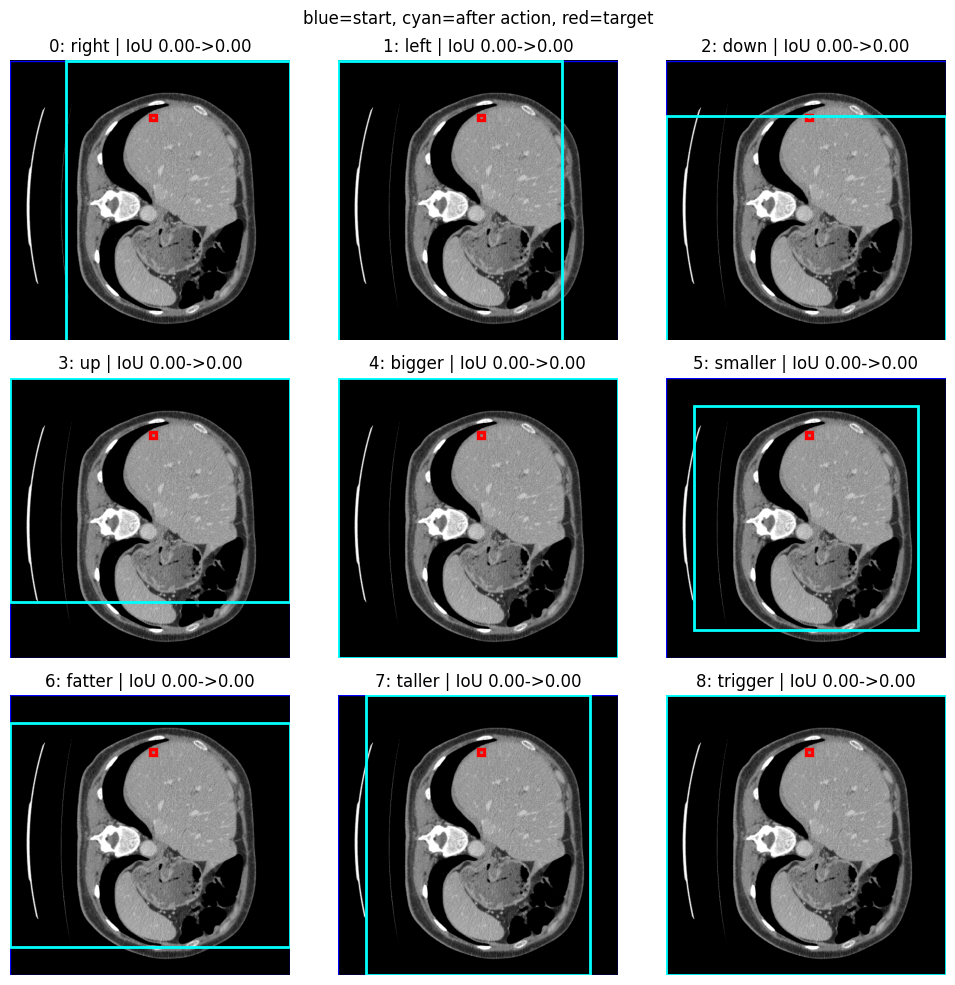

In [7]:
def show_action_panel(record):
    e=Caicedo2DEnv([record],reward_mode=REWARD_MODE); e.reset(record=record)
    fig,axes=plt.subplots(3,3,figsize=(10,10)); axes=axes.ravel()
    for a in range(NUM_ACTIONS):
        ax=axes[a]
        ax.imshow(e.image,cmap='gray',vmin=0,vmax=1)
        other=[b for b in e.record.get('boxes',e.reward_boxes) if list(b)!=list(e.target_box)]
        draw_boxes(ax,other,color='orange',linewidth=1.4)
        draw_boxes(ax,[e.target_box],color='red',linewidth=2.4)
        draw_boxes(ax,[e.box],color='blue',linewidth=1)
        nb=apply_action_2d(e.box,a,e.image.shape,alpha=e.alpha)
        draw_boxes(ax,[nb],color='cyan',linewidth=2)
        ni=max_iou_2d(nb,e.reward_boxes)
        ax.set_title(f'{a}: {ACTION_NAMES[a]} | IoU {e.prev_iou:.2f}->{ni:.2f}')
        ax.axis('off')
    plt.suptitle('blue=start, cyan=after action, red=target')
    plt.tight_layout(); plt.show()

show_action_panel(train_records[0])


## Greedy Oracle Check

Verifies that the action space can reach useful lesion boxes.


In [8]:
def greedy_oracle_rollout(record, reward_mode=REWARD_MODE, max_steps=MAX_STEPS):
    e=Caicedo2DEnv([record],reward_mode=reward_mode,max_steps=max_steps)
    obs,info=e.reset(record=record)
    frames=[{'step':0,'box':e.box.copy(),'iou':info['iou'],'action':None}]
    done=False
    while not done:
        best_a,best_iou=0,-1.0
        for a in range(8):
            nb=apply_action_2d(e.box,a,e.image.shape,alpha=e.alpha)
            ni=max_iou_2d(nb,e.reward_boxes)
            if ni>best_iou: best_iou,best_a=ni,a
        if e.prev_iou>=TRIGGER_IOU: best_a=8
        obs,reward,done,info=e.step(best_a)
        frames.append({'step':e.step_count,'box':e.box.copy(),'iou':info['iou'],'action':best_a})
    return e,frames,info

def oracle_summary(records, n=None):
    if n is not None: records=records[:n]
    results=[]
    for rec in records:
        _,frames,info=greedy_oracle_rollout(rec)
        results.append({'best_iou':max(f['iou'] for f in frames),
                        'triggered':info['triggered'],'steps':info['steps']})
    best=np.array([r['best_iou'] for r in results],dtype=np.float32)
    trig=np.array([r['triggered'] for r in results],dtype=np.float32)
    steps=np.array([r['steps'] for r in results],dtype=np.float32)
    return {'n':len(results),'mean_best_iou':float(best.mean()),
            'success_best@0.25':float((best>=0.25).mean()),
            'success_best@0.5':float((best>=0.50).mean()),
            'trigger_rate':float(trig.mean()),'mean_steps':float(steps.mean())}

summary=oracle_summary(val_records)
log_line(json.dumps(summary,indent=2))
assert summary['success_best@0.25']>0.0,'Oracle cannot solve IoU@0.25'

oracle_summary_df = pd.DataFrame([{"split": "validation", **summary}])
display(oracle_summary_df)


,split,n,mean_best_iou,success_best@0.25,success_best@0.5,trigger_rate,mean_steps
0,validation,100,0.543473,0.98,0.94,0.94,18.27


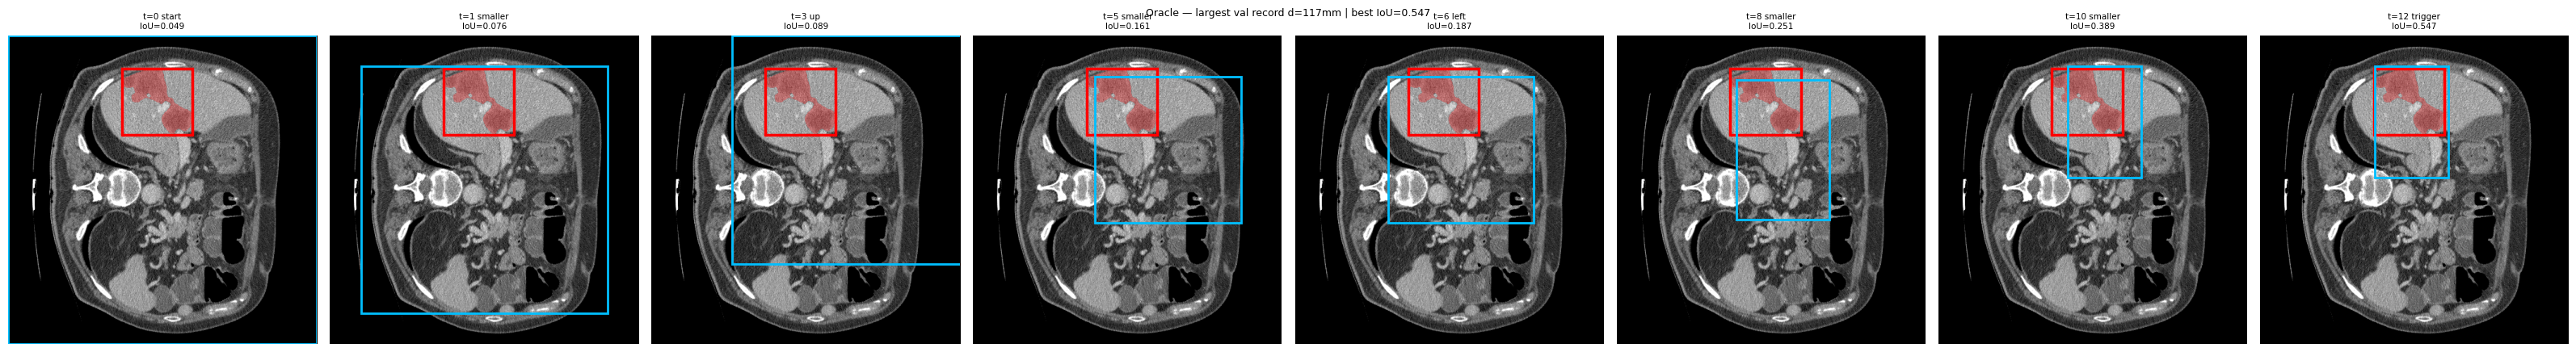

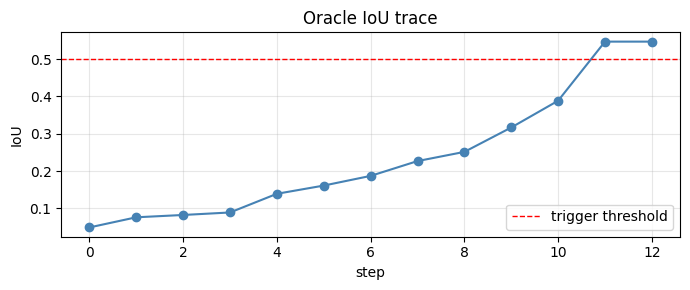

In [9]:
def visualize_rollout(env_obj, frames, title='Rollout', save_path=None):
    idxs=np.unique(np.linspace(0,len(frames)-1,min(8,len(frames)),dtype=int))
    fig,axes=plt.subplots(1,len(idxs),figsize=(4.0*len(idxs),4.4))
    if len(idxs)==1: axes=[axes]
    mask=None
    try:
        seg=CACHE.get_seg(env_obj.record['vid'])
        raw=( seg[:,:,env_obj.record['slice']]==2)
        if raw.any(): mask=raw
    except Exception: pass
    target_box=getattr(env_obj,'target_box',None)
    all_boxes=env_obj.record.get('boxes',[])
    other=[b for b in all_boxes if list(np.asarray(b,int))!=list(np.asarray(target_box,int))] if target_box is not None else all_boxes
    for ax,idx in zip(axes,idxs):
        fr=frames[idx]
        ax.imshow(env_obj.image,cmap='gray',vmin=0,vmax=1)
        if mask is not None:
            ax.imshow(np.ma.masked_where(~mask,np.ones_like(mask,dtype=float)),cmap='autumn',alpha=0.30)
        if other: draw_boxes(ax,other,color='orange',linewidth=1.2,linestyle='--')
        if target_box is not None: draw_boxes(ax,[target_box],color='red',linewidth=2.5)
        draw_boxes(ax,[fr['box']],color='deepskyblue',linewidth=2)
        act='start' if fr['action'] is None else ACTION_NAMES[fr['action']]
        ax.set_title(f't={fr["step"]} {act}\nIoU={fr["iou"]:.3f}',fontsize=7.5)
        ax.axis('off')
    plt.suptitle(title,fontsize=9); plt.tight_layout()
    if save_path: plt.savefig(save_path,dpi=160,bbox_inches='tight')
    plt.show(); return fig

large_val=sorted(val_records,key=lambda r:float(r.get('diameter_mm',0)),reverse=True)
oe,of,_=greedy_oracle_rollout(large_val[0])
visualize_rollout(oe,of,f'Oracle — largest val record d={large_val[0].get("diameter_mm",0):.0f}mm | best IoU={max(f["iou"] for f in of):.3f}')
plt.figure(figsize=(7,3))
plt.plot([f['iou'] for f in of],marker='o',color='steelblue')
plt.axhline(TRIGGER_IOU,color='red',linestyle='--',linewidth=1,label='trigger threshold')
plt.xlabel('step'); plt.ylabel('IoU'); plt.title('Oracle IoU trace'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Visual Encoder

Loads the frozen visual feature extractor used by the baseline model.


In [10]:
class VGG16FC6Extractor(nn.Module):
    """Caicedo-style frozen VGG16 fc6 encoder — returns a 4096-d feature vector."""
    def __init__(self, pretrained=True):
        super().__init__()
        if models is None: raise RuntimeError('torchvision required')
        try:
            vgg=models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None)
            self.pretrained=pretrained
        except Exception as e:
            log_line(f'WARNING: {e}; using random weights')
            vgg=models.vgg16(weights=None); self.pretrained=False
        self.features=vgg.features; self.avgpool=vgg.avgpool; self.fc6=vgg.classifier[0]
        for p in self.parameters(): p.requires_grad=False
        self.eval()
        self.register_buffer('mean',torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer('std', torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))
    def train(self,mode=True): super().train(False); return self
    @torch.inference_mode()
    def forward(self,crop_batch):
        x=crop_batch.repeat(1,3,1,1); x=(x-self.mean)/self.std
        x=self.features(x); x=self.avgpool(x); x=torch.flatten(x,1); x=self.fc6(x)
        return x

feature_extractor=VGG16FC6Extractor(pretrained=True).to(DEVICE)
with torch.inference_mode():
    dummy_feat=feature_extractor(torch.zeros(2,1,IMG_SIZE,IMG_SIZE,device=DEVICE))
log_line(f'feature shape={tuple(dummy_feat.shape)}, pretrained={feature_extractor.pretrained}')
assert dummy_feat.shape==(2,4096)

encoder_summary_df = pd.DataFrame([
    {"metric": "pretrained", "value": feature_extractor.pretrained},
    {"metric": "feature_shape", "value": str(tuple(dummy_feat.shape))},
])
display(encoder_summary_df)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 240MB/s]


,metric,value
0,pretrained,True
1,feature_shape,"(2, 4096)"


## Q-Network and Replay

Defines the value network, action selection, replay buffer, and optimizer.


In [11]:
class CaicedoQNetwork(nn.Module):
    """
    Single-head Q-network per Caicedo §3.2.
    Input : VGG16-fc6 (4096) + box features (8) + history (90) = 4194-d
    Output: Q-values for 9 actions (8 movement + 1 trigger)
    Trigger is action index 8, trained purely by Bellman Q-loss.
    """
    def __init__(self, feature_dim=4096, history_dim=HISTORY_LEN*NUM_ACTIONS,
                 box_dim=BOX_FEATURE_DIM, hidden=1024, n_actions=NUM_ACTIONS):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(feature_dim+history_dim+box_dim, hidden),
            nn.ReLU(inplace=True), nn.Dropout(DROPOUT),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True), nn.Dropout(DROPOUT),
            nn.Linear(hidden, n_actions),
        )
    def forward(self, features, history, box_features):
        return self.net(torch.cat([features, history, box_features], dim=1))


Transition=namedtuple('Transition',
    ['feat','hist','box_feat','action','reward','next_feat','next_hist','next_box_feat','done'])

class ReplayBuffer:
    def __init__(self,capacity):
        self.capacity=int(capacity); self.buffer=deque(maxlen=self.capacity)
    def push(self,*args): self.buffer.append(Transition(*args))
    def sample(self,batch_size):
        batch=random.sample(self.buffer,batch_size); return Transition(*zip(*batch))
    def __len__(self): return len(self.buffer)


q_net=CaicedoQNetwork().to(DEVICE)
target_net=CaicedoQNetwork().to(DEVICE)
target_net.load_state_dict(q_net.state_dict()); target_net.eval()
optimizer=torch.optim.Adam(q_net.parameters(),lr=LR)
replay=ReplayBuffer(REPLAY_SIZE)


def box_features_from_obs(obs):
    x1,y1,x2,y2=obs['box'].astype(np.float32); h,w=obs['image_shape'].astype(np.float32)
    bw=max(1.0,x2-x1); bh=max(1.0,y2-y1); cx=x1+0.5*bw; cy=y1+0.5*bh
    return np.array([x1/w,y1/h,x2/w,y2/h,cx/w,cy/h,bw/w,bh/h],dtype=np.float32)

def obs_to_tensors(obs):
    crop=torch.from_numpy(obs['crop']).unsqueeze(0).to(DEVICE)
    hist=torch.from_numpy(obs['history']).unsqueeze(0).float().to(DEVICE)
    bf=torch.from_numpy(box_features_from_obs(obs)).unsqueeze(0).float().to(DEVICE)
    with torch.inference_mode(): feat=feature_extractor(crop).detach()
    return feat,hist,bf

def masked_argmax(q_values, env, previous_action=None):
    """Argmax with reversal and no-op suppression."""
    allowed=env.available_actions(previous_action)
    if len(allowed)==NUM_ACTIONS: return int(torch.argmax(q_values,dim=1).item())
    mask=torch.full_like(q_values,float('-inf'))
    for a in allowed: mask[:,a]=0.0
    return int(torch.argmax(q_values+mask,dim=1).item())

def select_action_from_tensors(env, feat, hist, box_feat, epsilon):
    if random.random()<epsilon:
        if GUIDED_EXPLORATION:
            if env.prev_iou>=TRIGGER_IOU and random.random()<TRIGGER_DEMO_PROB: return 8
            return int(random.choice(env.positive_actions()))
        return int(random.choice(env.available_actions(env.last_action)))
    q_net.eval()
    with torch.no_grad(): q_values=q_net(feat,hist,box_feat)
    return masked_argmax(q_values,env,env.last_action)

def select_action(env,obs,epsilon):
    feat,hist,bf=obs_to_tensors(obs); return select_action_from_tensors(env,feat,hist,bf,epsilon)

def push_transition(feat,hist,bf,action,reward,nf,nh,nbf,done):
    replay.push(feat.detach().cpu(),hist.detach().cpu(),bf.detach().cpu(),int(action),float(reward),
                nf.detach().cpu(),nh.detach().cpu(),nbf.detach().cpu(),float(done))

def optimize_step():
    if len(replay)<max(BATCH_SIZE,LEARNING_STARTS): return None
    q_net.train(); target_net.eval()
    batch=replay.sample(BATCH_SIZE)
    feat=torch.cat(batch.feat).to(DEVICE); hist=torch.cat(batch.hist).to(DEVICE)
    bf=torch.cat(batch.box_feat).to(DEVICE)
    nf=torch.cat(batch.next_feat).to(DEVICE); nh=torch.cat(batch.next_hist).to(DEVICE)
    nbf=torch.cat(batch.next_box_feat).to(DEVICE)
    action=torch.tensor(batch.action,dtype=torch.long,device=DEVICE)
    reward=torch.tensor(batch.reward,dtype=torch.float32,device=DEVICE)
    done=torch.tensor(batch.done,dtype=torch.float32,device=DEVICE)

    q_values=q_net(feat,hist,bf)
    q_sa=q_values.gather(1,action.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q=target_net(nf,nh,nbf).max(dim=1).values
        target=reward+GAMMA*(1.0-done)*next_q
    loss=F.smooth_l1_loss(q_sa,target)
    optimizer.zero_grad(set_to_none=True); loss.backward()
    torch.nn.utils.clip_grad_norm_(q_net.parameters(),10.0)
    optimizer.step(); return float(loss.item())

log_line(q_net)
log_line(f'Total parameters: {sum(p.numel() for p in q_net.parameters()):,}')

model_summary_df = pd.DataFrame([
    {"component": "q_network", "trainable_parameters": sum(p.numel() for p in q_net.parameters())},
])
display(model_summary_df)


,component,trainable_parameters
0,q_network,5354505


## Evaluation Protocol

Computes the same final, best, trigger, timeout, and step metrics used for the improvements.


In [12]:
def policy_selection_score(s):
    return (s['success_final@0.25']+0.5*s['success_final@0.5']
            +0.5*s['successful_trigger_rate']-0.25*s['bad_trigger_rate']-0.1*s['timeout_rate'])

def localization_score(s):
    return s['success_best@0.25']+s['success_best@0.5']+0.1*s['mean_best_iou']


def evaluate_dqn(records, n=None, render_one=False, use_stagnation=True):
    if n is not None: records=records[:n]
    results=[]; example=None; q_net.eval()
    for rec in records:
        e=Caicedo2DEnv([rec],reward_mode=REWARD_MODE)
        obs,info=e.reset(record=rec)
        frames=[{'step':0,'box':e.box.copy(),'iou':info['iou'],'action':None}]
        prev_pa=None; prev_ga=None; pol_rev=0; greed_rev=0
        best_seen=float(info['best_iou']); stagnant=0; done=False
        while not done:
            feat,hist,bf=obs_to_tensors(obs)
            with torch.no_grad():
                q_values=q_net(feat,hist,bf)
                ga=int(torch.argmax(q_values,dim=1).item())
                action=masked_argmax(q_values,e,e.last_action)
            if use_stagnation and action!=8 and stagnant>=STAGNATION_PATIENCE and e.prev_iou>=STAGNATION_TRIGGER_IOU:
                action=8
            if prev_pa is not None and action<8 and OPPOSITE.get(prev_pa)==action: pol_rev+=1
            if prev_ga is not None and ga<8 and OPPOSITE.get(prev_ga)==ga: greed_rev+=1
            prev_pa=action; prev_ga=ga
            obs,reward,done,info=e.step(action)
            frames.append({'step':e.step_count,'box':e.box.copy(),'iou':info['iou'],'action':action})
            if not done:
                if info['best_iou']>best_seen+1e-6: best_seen=float(info['best_iou']); stagnant=0
                else: stagnant+=1
        results.append({'final_iou':float(info['iou']),'best_iou':float(info['best_iou']),
                        'triggered':bool(info['triggered']),
                        'good_trigger':bool(info['triggered'] and info['iou']>=TRIGGER_IOU),
                        'bad_trigger': bool(info['triggered'] and info['iou']<TRIGGER_IOU),
                        'timed_out':bool(info['timed_out']),'steps':int(info['steps']),
                        'policy_reversals':int(pol_rev),'would_be_reversals':int(greed_rev),
                        'diameter_mm':float(info['target_2d_diameter_mm']),
                        'target_2d_diameter_mm':float(info['target_2d_diameter_mm'])})
        if render_one and example is None: example=(e,frames)
    return summarize_eval(results),example


def evaluate_random_movement_only(records, n=None):
    """Fair random baseline: movement-only for MAX_STEPS-1 steps, trigger on last if IoU good."""
    if n is not None: records=records[:n]
    results=[]
    for rec in records:
        e=Caicedo2DEnv([rec],reward_mode=REWARD_MODE); obs,info=e.reset(record=rec)
        done=False; prev_a=None; pol_rev=0
        while not done:
            allowed=[a for a in e.available_actions(e.last_action) if a<8]
            if not allowed: allowed=list(range(8))
            action=8 if (e.step_count>=e.max_steps-1 and e.prev_iou>=TRIGGER_IOU) else int(random.choice(allowed))
            if prev_a is not None and action<8 and OPPOSITE.get(prev_a)==action: pol_rev+=1
            prev_a=action; obs,reward,done,info=e.step(action)
        results.append({'final_iou':float(info['iou']),'best_iou':float(info['best_iou']),
                        'triggered':bool(info['triggered']),
                        'good_trigger':bool(info['triggered'] and info['iou']>=TRIGGER_IOU),
                        'bad_trigger': bool(info['triggered'] and info['iou']<TRIGGER_IOU),
                        'timed_out':bool(info['timed_out']),'steps':int(info['steps']),
                        'policy_reversals':int(pol_rev),'would_be_reversals':int(pol_rev),
                        'diameter_mm':float(info['target_2d_diameter_mm']),
                        'target_2d_diameter_mm':float(info['target_2d_diameter_mm'])})
    return summarize_eval(results)


def _mean_with_ci(values):
    arr=np.asarray(values,dtype=np.float32); n=int(arr.size)
    if n==0: return {'mean':0.0,'std':0.0,'n':0,'ci95':0.0}
    mean=float(arr.mean()); std=float(arr.std(ddof=1)) if n>1 else 0.0
    ci95=float(1.96*std/np.sqrt(n)) if n>1 else 0.0
    return {'mean':mean,'std':std,'n':n,'ci95':ci95}


def _summarize_subset(results):
    if not results: return {'n':0}
    fi=np.array([r['final_iou']  for r in results],dtype=np.float32)
    bi=np.array([r['best_iou']   for r in results],dtype=np.float32)
    tr=np.array([r['triggered']  for r in results],dtype=np.float32)
    gt=np.array([r['good_trigger'] for r in results],dtype=np.float32)
    bt=np.array([r['bad_trigger']  for r in results],dtype=np.float32)
    to=np.array([r['timed_out']  for r in results],dtype=np.float32)
    st=np.array([r['steps']      for r in results],dtype=np.float32)
    pr=np.array([r.get('policy_reversals',0) for r in results],dtype=np.float32)
    gr=np.array([r.get('would_be_reversals',0) for r in results],dtype=np.float32)
    tri=fi[tr.astype(bool)]
    return {'n':len(results),
            'mean_final_iou':float(fi.mean()),'mean_best_iou':float(bi.mean()),
            'success_final@0.25':float((fi>=0.25).mean()),'success_final@0.5':float((fi>=0.50).mean()),
            'success_best@0.25':float((bi>=0.25).mean()),'success_best@0.5':float((bi>=0.50).mean()),
            'trigger_rate':float(tr.mean()),'successful_trigger_rate':float(gt.mean()),
            'bad_trigger_rate':float(bt.mean()),'mean_trigger_iou':float(tri.mean()) if len(tri) else 0.0,
            'timeout_rate':float(to.mean()),'mean_steps':float(st.mean()),
            'mean_policy_reversals':float(pr.mean()),'mean_would_be_reversals':float(gr.mean()),
            'best_box_mean_iou':float(bi.mean()),
            'good_stop_rate':float(gt.mean()),'bad_stop_rate':float(bt.mean()),'stop_rate':float(tr.mean()),
            'ci':{
                'final_iou':_mean_with_ci(fi),'best_iou':_mean_with_ci(bi),
                'success_best@0.25':_mean_with_ci((bi>=0.25).astype(np.float32)),
                'success_best@0.5': _mean_with_ci((bi>=0.50).astype(np.float32)),
                'success_final@0.5':_mean_with_ci((fi>=0.50).astype(np.float32)),
                'trigger_rate':_mean_with_ci(tr),'successful_trigger_rate':_mean_with_ci(gt),
                'bad_trigger_rate':_mean_with_ci(bt),'timeout_rate':_mean_with_ci(to),
                'steps':_mean_with_ci(st),'policy_reversals':_mean_with_ci(pr),
                'would_be_reversals':_mean_with_ci(gr),
            }}

SIZE_BUCKETS=[('small',lambda d:d<15.0),('medium',lambda d:15.0<=d<30.0),('large',lambda d:d>=30.0)]

def summarize_eval(results):
    if not results: return {'n':0}
    s=_summarize_subset(results)
    s['by_size']={name:_summarize_subset([r for r in results if pred(float(r.get('diameter_mm',0.0)))]) for name,pred in SIZE_BUCKETS}
    return s


log_line('Random baseline (movement-only):')
rand_quick=evaluate_random_movement_only(val_records, n=min(32,len(val_records)))
log_line(json.dumps({k:v for k,v in rand_quick.items() if k!='by_size'},indent=2))


## Training Procedure

Runs baseline training and records epoch-level validation logs.


In [13]:
def epsilon_for_epoch(epoch_idx):
    if epoch_idx>=EPS_ANNEAL_EPOCHS: return EPS_END
    frac=epoch_idx/max(1,EPS_ANNEAL_EPOCHS)
    return EPS_START+frac*(EPS_END-EPS_START)

train_history={'episode_reward':[],'episode_best_iou':[],'loss':[],
    'val_best_iou':[],'val_success@0.25':[],'val_success@0.5':[],
    'val_trigger_rate':[],'val_successful_trigger_rate':[],
    'val_bad_trigger_rate':[],'val_timeout_rate':[],
    'val_checkpoint_score':[],'val_localization_score':[],
    'epoch_loss_mean':[],'env_steps':[],'wall_clock_seconds':[]}

global_step=0; best_policy_score=-float('inf'); best_loc_score=-float('inf')
best_policy_epoch=None; best_loc_epoch=None; start_time=time.time()

best_policy_ckpt_path=os.path.join(OUT_DIR,'caicedo_2d_dqn_best_policy.pt')
best_loc_ckpt_path   =os.path.join(OUT_DIR,'caicedo_2d_dqn_best_localization.pt')
final_ckpt_path      =os.path.join(OUT_DIR,'caicedo_2d_dqn_final.pt')

for epoch in range(TRAIN_EPOCHS):
    epsilon=epsilon_for_epoch(epoch)
    random.shuffle(train_records)
    epoch_rewards=[]; epoch_best=[]; epoch_losses=[]

    for rec in train_records:
        e=Caicedo2DEnv([rec],reward_mode=REWARD_MODE)
        obs,info=e.reset(record=rec); done=False; ep_reward=0.0
        feat,hist,bf=obs_to_tensors(obs)
        while not done:
            action=select_action_from_tensors(e,feat,hist,bf,epsilon)
            next_obs,reward,done,info=e.step(action)
            nf,nh,nbf=obs_to_tensors(next_obs)
            push_transition(feat,hist,bf,action,reward,nf,nh,nbf,done)


            if (not done) and info['iou']>=TRIGGER_IOU and TRIGGER_POSITIVE_REPLAY>0:
                for _ in range(TRIGGER_POSITIVE_REPLAY):
                    push_transition(nf,nh,nbf,8,TRIGGER_REWARD,nf,nh,nbf,True)


            if (not done) and TRIGGER_NEGATIVE_MIN_IOU<=info['iou']<TRIGGER_IOU and TRIGGER_NEGATIVE_REPLAY>0:
                for _ in range(TRIGGER_NEGATIVE_REPLAY):
                    push_transition(nf,nh,nbf,8,-TRIGGER_REWARD,nf,nh,nbf,True)

            if global_step%TRAIN_EVERY==0:
                loss=optimize_step()
                if loss is not None: epoch_losses.append(loss); train_history['loss'].append(loss)
            if global_step%TARGET_UPDATE_EVERY==0 and global_step>0:
                target_net.load_state_dict(q_net.state_dict())

            obs=next_obs; feat,hist,bf=nf,nh,nbf; ep_reward+=reward; global_step+=1
        epoch_rewards.append(ep_reward); epoch_best.append(info['best_iou'])

    val_summary,_=evaluate_dqn(val_records,n=min(64,len(val_records)),use_stagnation=True)
    ps=policy_selection_score(val_summary); ls=localization_score(val_summary)

    train_history['episode_reward'].append(float(np.mean(epoch_rewards)))
    train_history['episode_best_iou'].append(float(np.mean(epoch_best)))
    train_history['val_best_iou'].append(val_summary['mean_best_iou'])
    train_history['val_success@0.25'].append(val_summary['success_best@0.25'])
    train_history['val_success@0.5'].append(val_summary['success_best@0.5'])
    train_history['val_trigger_rate'].append(val_summary['trigger_rate'])
    train_history['val_successful_trigger_rate'].append(val_summary['successful_trigger_rate'])
    train_history['val_bad_trigger_rate'].append(val_summary['bad_trigger_rate'])
    train_history['val_timeout_rate'].append(val_summary['timeout_rate'])
    train_history['val_checkpoint_score'].append(float(ps))
    train_history['val_localization_score'].append(float(ls))
    train_history['epoch_loss_mean'].append(float(np.mean(epoch_losses)) if epoch_losses else float('nan'))
    train_history['env_steps'].append(int(global_step))
    train_history['wall_clock_seconds'].append(float(time.time()-start_time))

    ckpt_config={'alpha':ALPHA,'max_steps':MAX_STEPS,'trigger_iou':TRIGGER_IOU,
        'reward_mode':REWARD_MODE,'label_source':LABEL_SOURCE,
        'max_train_records':MAX_TRAIN_RECORDS,'max_val_records':MAX_VAL_RECORDS,
        'history_len':HISTORY_LEN,'img_size':IMG_SIZE,'context_pad_px':CONTEXT_PAD_PX,
        'box_feature_dim':BOX_FEATURE_DIM,'suppress_reversals':SUPPRESS_REVERSALS,
        'mask_noop_actions':MASK_NOOP_ACTIONS,
        'trigger_positive_replay':TRIGGER_POSITIVE_REPLAY,
        'trigger_negative_replay':TRIGGER_NEGATIVE_REPLAY,
        'trigger_negative_min_iou':TRIGGER_NEGATIVE_MIN_IOU,
        'stagnation_patience':STAGNATION_PATIENCE,'stagnation_trigger_iou':STAGNATION_TRIGGER_IOU}

    if ps>best_policy_score:
        best_policy_score=float(ps); best_policy_epoch=epoch+1
        torch.save({'q_net':q_net.state_dict(),'target_net':target_net.state_dict(),
            'config':ckpt_config,'train_history':train_history,
            'selection':{'epoch':best_policy_epoch,'score':best_policy_score,
                         'val_summary':val_summary,'selection_type':'policy'}},best_policy_ckpt_path)
    if ls>best_loc_score:
        best_loc_score=float(ls); best_loc_epoch=epoch+1
        torch.save({'q_net':q_net.state_dict(),'target_net':target_net.state_dict(),
            'config':ckpt_config,'train_history':train_history,
            'selection':{'epoch':best_loc_epoch,'score':best_loc_score,
                         'val_summary':val_summary,'selection_type':'localization'}},best_loc_ckpt_path)

    log_line(f'epoch {epoch+1:02d}/{TRAIN_EPOCHS} | eps={epsilon:.3f} | '
          f'train_reward={np.mean(epoch_rewards):.2f} | train_best_iou={np.mean(epoch_best):.3f} | '
          f'loss={np.mean(epoch_losses) if epoch_losses else float("nan"):.4f} | '
          f'val_best_iou={val_summary["mean_best_iou"]:.3f} | '
          f'val_best@.25={val_summary["success_best@0.25"]:.3f} | '
          f'val_best@.50={val_summary["success_best@0.5"]:.3f} | '
          f'val_good_stop={val_summary["good_stop_rate"]:.3f} | '
          f'val_bad_stop={val_summary["bad_stop_rate"]:.3f} | '
          f'val_timeout={val_summary["timeout_rate"]:.3f} | '
          f'policy_score={ps:.3f} | loc_score={ls:.3f}')

lc_path=os.path.join(OUT_DIR,'learning_curve.csv')
lc_fields=['epoch','env_steps','wall_clock_seconds','episode_reward','episode_best_iou',
    'epoch_loss_mean','val_best_iou','val_success@0.25','val_success@0.5',
    'val_successful_trigger_rate','val_bad_trigger_rate','val_timeout_rate',
    'val_checkpoint_score','val_localization_score']
with open(lc_path,'w',newline='') as f:
    w=csv.DictWriter(f,fieldnames=lc_fields); w.writeheader()
    for i in range(len(train_history['episode_reward'])):
        w.writerow({field:(i+1 if field=='epoch' else train_history[field][i]) for field in lc_fields})

log_line(f'training done in {(time.time()-start_time)/60:.1f}min, steps={global_step}, replay={len(replay)}')
log_line(f'best policy epoch={best_policy_epoch} score={best_policy_score:.3f}')
log_line(f'best localization epoch={best_loc_epoch} score={best_loc_score:.3f}')
torch.save({'q_net':q_net.state_dict(),'target_net':target_net.state_dict(),
    'config':ckpt_config,'train_history':train_history,
    'selection':{'best_policy_epoch':best_policy_epoch,'best_policy_score':best_policy_score,
                 'best_loc_epoch':best_loc_epoch,'best_loc_score':best_loc_score}},final_ckpt_path)
log_line(f'saved final checkpoint -> {final_ckpt_path}')


## Training Diagnostics

Displays training logs as a table and plots the main learning curves.


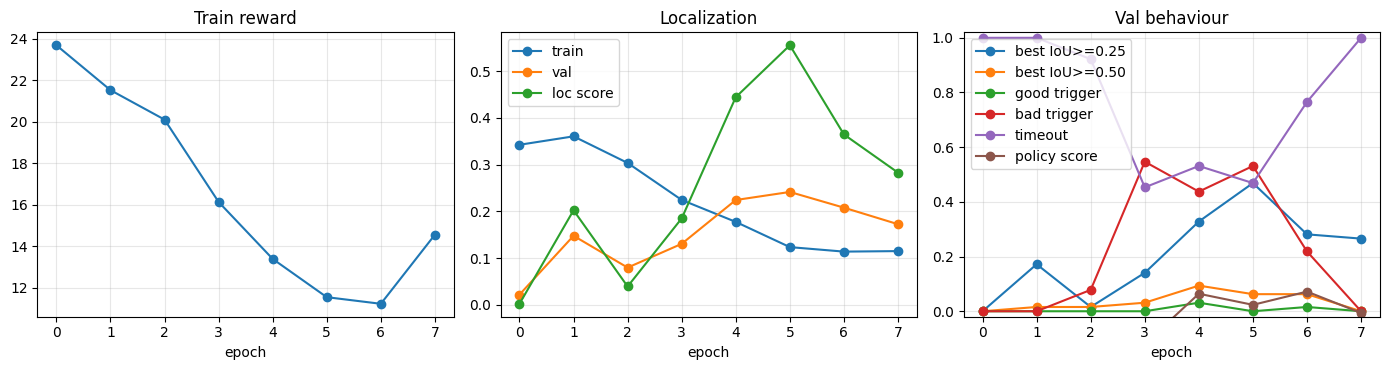

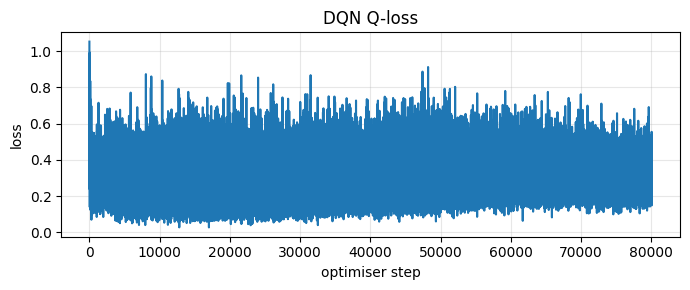

,epoch,episode_reward,episode_best_iou,epoch_loss_mean,val_best_iou,val_success_best@0.25,val_success_best@0.5,val_good_trigger_rate,val_bad_trigger_rate,val_timeout_rate,policy_score,localization_score
0,1,23.696667,0.342431,0.282732,0.021742,0.000000,0.000000,0.000000,0.000000,1.000000,-0.100000,0.002174
1,2,21.530000,0.360495,0.270471,0.147721,0.171875,0.015625,0.000000,0.000000,1.000000,-0.084375,0.202272
2,3,20.106667,0.303569,0.270590,0.079620,0.015625,0.015625,0.000000,0.078125,0.921875,-0.111719,0.039212
3,4,16.130000,0.224355,0.283274,0.130507,0.140625,0.031250,0.000000,0.546875,0.453125,-0.119531,0.184926
4,5,13.380000,0.177420,0.297595,0.224247,0.328125,0.093750,0.031250,0.437500,0.531250,0.064062,0.444300
5,6,11.533333,0.123467,0.318653,0.241487,0.468750,0.062500,0.000000,0.531250,0.468750,0.023438,0.555399
6,7,11.213333,0.113835,0.320216,0.207876,0.281250,0.062500,0.015625,0.218750,0.765625,0.071875,0.364538
7,8,14.550000,0.114925,0.304483,0.172482,0.265625,0.000000,0.000000,0.000000,1.000000,-0.006250,0.282873


In [14]:
fig,axes=plt.subplots(1,3,figsize=(14,3.8))
axes[0].plot(train_history['episode_reward'],marker='o')
axes[0].set_title('Train reward'); axes[0].set_xlabel('epoch'); axes[0].grid(alpha=0.3)
axes[1].plot(train_history['episode_best_iou'],marker='o',label='train')
axes[1].plot(train_history['val_best_iou'],marker='o',label='val')
axes[1].plot(train_history['val_localization_score'],marker='o',label='loc score')
axes[1].set_title('Localization'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(train_history['val_success@0.25'],marker='o',label='best IoU>=0.25')
axes[2].plot(train_history['val_success@0.5'],marker='o',label='best IoU>=0.50')
axes[2].plot(train_history['val_successful_trigger_rate'],marker='o',label='good trigger')
axes[2].plot(train_history['val_bad_trigger_rate'],marker='o',label='bad trigger')
axes[2].plot(train_history['val_timeout_rate'],marker='o',label='timeout')
axes[2].plot(train_history['val_checkpoint_score'],marker='o',label='policy score')
axes[2].set_title('Val behaviour'); axes[2].set_xlabel('epoch')
axes[2].set_ylim(-0.02,1.02); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
if train_history['loss']:
    plt.figure(figsize=(7,3))
    plt.plot(train_history['loss'])
    plt.title('DQN Q-loss'); plt.xlabel('optimiser step'); plt.ylabel('loss')
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

training_log_df = pd.DataFrame({
    "epoch": list(range(1, len(train_history["episode_reward"]) + 1)),
    "episode_reward": train_history["episode_reward"],
    "episode_best_iou": train_history["episode_best_iou"],
    "epoch_loss_mean": train_history["epoch_loss_mean"],
    "val_best_iou": train_history["val_best_iou"],
    "val_success_best@0.25": train_history["val_success@0.25"],
    "val_success_best@0.5": train_history["val_success@0.5"],
    "val_good_trigger_rate": train_history["val_successful_trigger_rate"],
    "val_bad_trigger_rate": train_history["val_bad_trigger_rate"],
    "val_timeout_rate": train_history["val_timeout_rate"],
    "policy_score": train_history["val_checkpoint_score"],
    "localization_score": train_history["val_localization_score"],
})
display(training_log_df)
training_log_table_path = os.path.join(OUT_DIR, "baseline_training_log_table.csv")
training_log_df.to_csv(training_log_table_path, index=False)


## Final Evaluation

Loads the selected checkpoint and reports validation, test, random, and qualitative outputs.


,split,n,mean_final_iou,mean_best_iou,success_final@0.25,success_final@0.5,success_best@0.25,success_best@0.5,trigger_rate,successful_trigger_rate,bad_trigger_rate,mean_trigger_iou,timeout_rate,mean_steps,mean_reversals
0,validation,100,0.133924,0.202569,0.210000,0.010000,0.320000,0.050000,0.240,0.01,0.230,0.187422,0.760,37.720001,0.0
1,test,128,0.056867,0.128674,0.054688,0.007812,0.226562,0.046875,0.125,0.00,0.125,0.124262,0.875,39.125000,0.0
2,test_random,128,0.019659,0.081943,0.023438,0.000000,0.101562,0.007812,0.000,0.00,0.000,0.000000,1.000,40.000000,0.0


,metric,value
0,selected_epoch,7.000000
1,selected_score,0.071875
2,validation_oracle_best_iou,0.543473


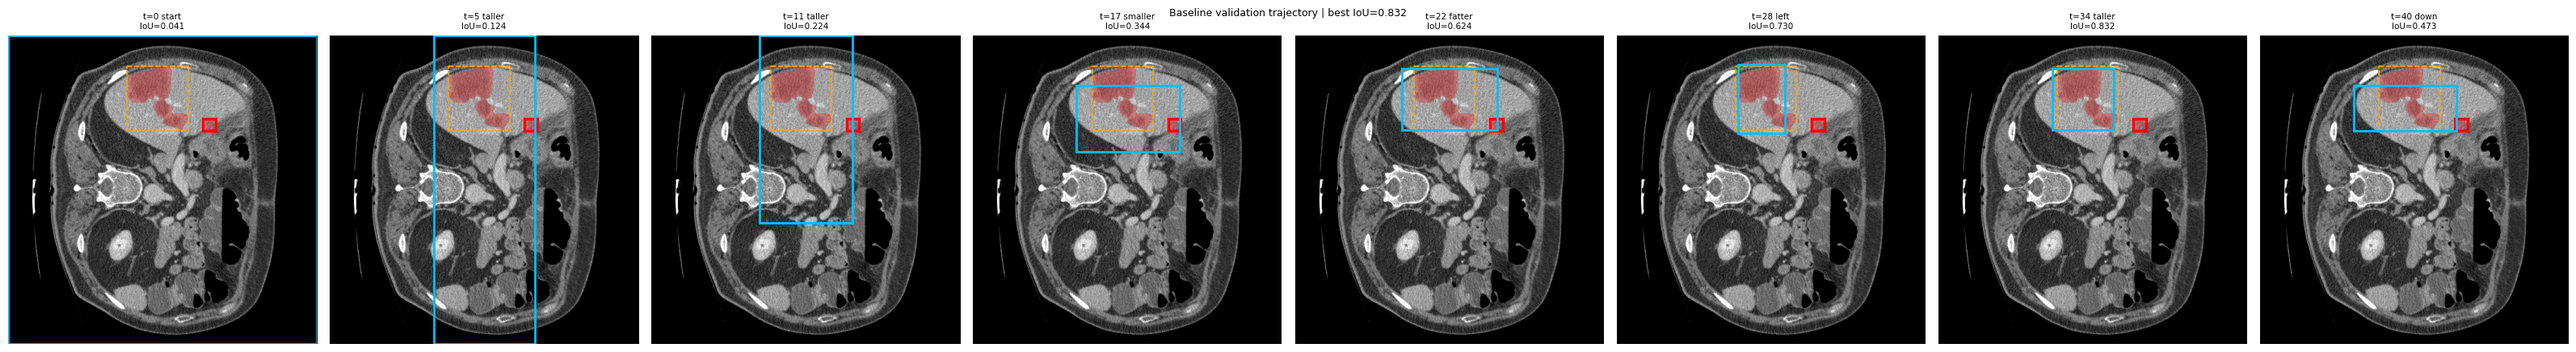

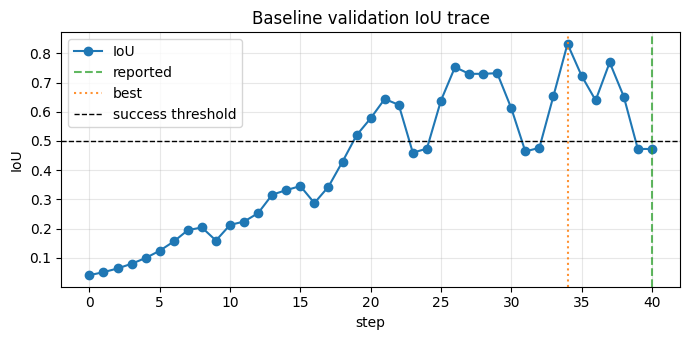

,volume,slice,best_step,best_iou,reported_step,reported_iou,actions
0,33,78,34,0.832147,40,0.472679,taller taller taller taller taller taller up f...


In [15]:
if os.path.exists(best_policy_ckpt_path):
    ckpt = torch.load(best_policy_ckpt_path, map_location=DEVICE)
    q_net.load_state_dict(ckpt["q_net"])
    selected_checkpoint = ckpt.get("selection", {})
else:
    selected_checkpoint = {}

val_summary, _ = evaluate_dqn(val_records, use_stagnation=True)
test_summary, _ = evaluate_dqn(test_records_for_reporting, use_stagnation=True)
rand_test = evaluate_random_movement_only(test_records_for_reporting)
oracle_val = oracle_summary(val_records)

REPORT_METRIC_COLUMNS = ['n', 'mean_final_iou', 'mean_best_iou', 'success_final@0.25', 'success_final@0.5', 'success_best@0.25', 'success_best@0.5', 'trigger_rate', 'successful_trigger_rate', 'bad_trigger_rate', 'mean_trigger_iou', 'timeout_rate', 'mean_steps', 'mean_reversals']

def report_metric_row(split, summary):
    row = {"split": split}
    for key in REPORT_METRIC_COLUMNS:
        if key == "mean_reversals":
            row[key] = summary.get("mean_reversals", summary.get("mean_policy_reversals", np.nan))
        else:
            row[key] = summary.get(key, np.nan)
    return row

final_eval_df = pd.DataFrame([
    report_metric_row("validation", val_summary),
    report_metric_row("test", test_summary),
    report_metric_row("test_random", rand_test),
])
display(final_eval_df)
final_eval_table_path = os.path.join(OUT_DIR, "baseline_final_eval_table.csv")
final_eval_df.to_csv(final_eval_table_path, index=False)

checkpoint_summary_df = pd.DataFrame([
    {"metric": "selected_epoch", "value": selected_checkpoint.get("epoch", np.nan)},
    {"metric": "selected_score", "value": selected_checkpoint.get("score", np.nan)},
    {"metric": "validation_oracle_best_iou", "value": oracle_val.get("mean_best_iou", np.nan)},
])
display(checkpoint_summary_df)

def get_dqn_rollouts(records):
    rollouts = []
    q_net.eval()
    for rec in records:
        e = Caicedo2DEnv([rec], reward_mode=REWARD_MODE)
        obs, info = e.reset(record=rec)
        frames = [{"step": 0, "box": e.box.copy(), "iou": info["iou"], "action": None}]
        best_seen = float(info["best_iou"])
        stagnant = 0
        done = False
        while not done:
            feat, hist, bf = obs_to_tensors(obs)
            with torch.no_grad():
                q_values = q_net(feat, hist, bf)
                action = masked_argmax(q_values, e, e.last_action)
            if action != 8 and stagnant >= STAGNATION_PATIENCE and e.prev_iou >= STAGNATION_TRIGGER_IOU:
                action = 8
            obs, reward, done, info = e.step(action)
            frames.append({"step": e.step_count, "box": e.box.copy(), "iou": info["iou"], "action": action})
            if not done:
                if info["best_iou"] > best_seen + 1e-6:
                    best_seen = float(info["best_iou"])
                    stagnant = 0
                else:
                    stagnant += 1
        rollouts.append({"score": max(float(f["iou"]) for f in frames), "env": e, "frames": frames, "info": info, "record": rec})
    return sorted(rollouts, key=lambda item: item["score"])

best_validation_rollout = get_dqn_rollouts(val_records)[-1]
best_frame = max(best_validation_rollout["frames"], key=lambda f: float(f["iou"]))
reported_frame = best_validation_rollout["frames"][-1]
scan_path = os.path.join(OUT_DIR, "baseline_best_validation_rollout.png")
visualize_rollout(
    best_validation_rollout["env"],
    best_validation_rollout["frames"],
    f"Baseline validation trajectory | best IoU={best_validation_rollout['score']:.3f}",
    save_path=scan_path,
)
plt.figure(figsize=(7, 3.5))
plt.plot([f["iou"] for f in best_validation_rollout["frames"]], marker="o", label="IoU")
plt.axvline(reported_frame["step"], color="tab:green", linestyle="--", alpha=0.75, label="reported")
plt.axvline(best_frame["step"], color="tab:orange", linestyle=":", alpha=0.85, label="best")
plt.axhline(TRIGGER_IOU, color="black", linestyle="--", linewidth=1, label="success threshold")
plt.title("Baseline validation IoU trace")
plt.xlabel("step")
plt.ylabel("IoU")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

qualitative_rollout_df = pd.DataFrame([{
    "volume": int(best_validation_rollout["env"].record["vid"]),
    "slice": int(best_validation_rollout["env"].record["slice"]),
    "best_step": int(best_frame["step"]),
    "best_iou": float(best_frame["iou"]),
    "reported_step": int(reported_frame["step"]),
    "reported_iou": float(reported_frame["iou"]),
    "actions": " ".join(ACTION_NAMES[f["action"]] for f in best_validation_rollout["frames"] if f["action"] is not None),
}])
display(qualitative_rollout_df)

metrics = {
    "validation": val_summary,
    "test": test_summary,
    "test_random": rand_test,
    "oracle_validation": oracle_val,
    "selected_checkpoint": selected_checkpoint,
}
metrics_path = os.path.join(OUT_DIR, "baseline_submission_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
